In [ ]:
import numpy as np 
import pandas as pd 
from pathlib import Path

# Data loading 
from src.core.data_loader import DataLoader

# Analyzers 
from src.core.one_way_interaction import OneWayInteractionAnalyzer
from src.core.nway_interaction import NWayInteractionAnalyzer                                    
from src.core.radial_distribution import RadialDistributionAnalyzer
from src.core.vol_spher_metrics import MorphologyMetricsAnalyzer 

### Introducing DataLoader 

The DataLoader is designed to act as an librarian. The data lives on disk in hundreds of folders and thousands of CSV files. The DataLoader provides the capabilities to search and sort those data to provide an access for all analyzer modules of the software. 

`detect_structure`: detects if the data is organised in a nested structure 

`find_cell_folders`: builds a catalog by scanning every folder, parse the names, and build an index: "cell 0h_1 + organelle ER lives at this path" 

`load_metric_file`: given a path, read the CSV, validate it, and convert to a numpy array 

DataLoader is for safe inport of all data files. 

We start by detecting the dir:

In [ ]:
parent = '/Users/philippkaintoch/Desktop/Test_Data/0_Hours'

loader = DataLoader(parent)
loader.detect_structure()
loader.search_dir           # Call attribute to see which path is detected and if we have a nested file organisation 

[INFO] Structure: Direct -> Dataset contains LD


PosixPath('/Users/philippkaintoch/Desktop/Test_Data/0_Hours')

Next we view the files that are detected: 

In [12]:
loader.find_cell_folders()
loader.unique_cells        # Here, we can do a check if every folder (or cell) is detected properly

[INFO] Found 50 unique cells
[INFO] Found 6 unique organelles: ER, G, LD, Ly, M, P


['0h_1',
 '0h_10',
 '0h_11',
 '0h_12',
 '0h_13',
 '0h_14',
 '0h_15',
 '0h_16',
 '0h_17',
 '0h_18',
 '0h_19',
 '0h_2',
 '0h_20',
 '0h_21',
 '0h_22',
 '0h_23',
 '0h_24',
 '0h_25',
 '0h_26',
 '0h_27',
 '0h_28',
 '0h_29',
 '0h_3',
 '0h_30',
 '0h_31',
 '0h_32',
 '0h_33',
 '0h_34',
 '0h_35',
 '0h_36',
 '0h_37',
 '0h_38',
 '0h_39',
 '0h_4',
 '0h_40',
 '0h_41',
 '0h_42',
 '0h_43',
 '0h_44',
 '0h_45',
 '0h_46',
 '0h_47',
 '0h_48',
 '0h_49',
 '0h_5',
 '0h_50',
 '0h_6',
 '0h_7',
 '0h_8',
 '0h_9']

The software is extremely fast by execessing the data. This comes due to the integration of a O(1) dictionary lookup strategy. Instead of building an index once upfront and loop through every folder when running an analysis I have build efficient dict structures: 

```{python}

# Dict 1: (cell_id, organelle) → folder info                                                                             
self._folder_lookup = {                                                                                               
    ('0h_1', 'ER'):  {'full_path': ..., 'cell_id': '0h_1', 'organelle': 'ER'},                                           
    ('0h_1', 'G'):   {'full_path': ..., 'cell_id': '0h_1', 'organelle': 'G'},                                            
    ('0h_1', 'LD'):  {'full_path': ..., 'cell_id': '0h_1', 'organelle': 'LD'},                                           
    ...  # 300 entries total                                                                                             
}                                                                                                                        
                                                                                                                        
# Dict 2: cell_id → list of its organelles                                                                               
self._cells_to_organelles = {                                                                                            
    '0h_1':  ['ER', 'G', 'LD', 'Ly', 'M', 'P'],                                                                          
    '0h_2':  ['ER', 'G', 'LD', 'Ly', 'M', 'P'],                                                                          
    ...                                                                                                                  
}                                                                                                                        
     

```

We can access a single lookup: 

In [16]:
loader._folder_lookup[("0h_1", "ER")]

{'full_path': PosixPath('/Users/philippkaintoch/Desktop/Test_Data/0_Hours/0h_1_ER_Statistics'),
 'folder_name': '0h_1_ER_Statistics',
 'cell_id': '0h_1',
 'organelle': 'ER'}

We can display everything nicely into a DataFrame. As you will recognise, the files are unsorted, as they are populate in whatever order `self.search_dir.iterdir()`returns files from the OS (essentially arbitrary). Everything downstream is sorted by the lookup folders (look at line above).

In [14]:
pd.DataFrame(loader.cell_folders[:5]) # first 5 folder entries as a table

,full_path,folder_name,cell_id,organelle
0,/Users/philippkaintoch/Desktop/Test_Data/0_Hou...,0h_32_G_Statistics,0h_32,G
1,/Users/philippkaintoch/Desktop/Test_Data/0_Hou...,0h_35_G_Statistics,0h_35,G
2,/Users/philippkaintoch/Desktop/Test_Data/0_Hou...,0h_49_M_Statistics,0h_49,M
3,/Users/philippkaintoch/Desktop/Test_Data/0_Hou...,0h_19_P_Statistics,0h_19,P
4,/Users/philippkaintoch/Desktop/Test_Data/0_Hou...,0h_9_G_Statistics,0h_9,G


### Running independent analysis 

The file sorting works very well. This can be used as basis to perform software-indepentent analysis so that the software dont need to be changed somehow. Analysis-Modes that are used very often can be later integrated into the software. I would recommend to dont change anything in the software except there is some coding experience with Object-Oriented Programming (OOP) you can build of. 

Here is a playground where you can try everything you might catch up in the web without disrupting the softwares capabilities. We start with one single file:

In [38]:
organelle = "ER"
cell_id = "0h_1"

folder = loader.get_folder_path(cell_id, organelle)
volume_file = folder / f"{cell_id}_{organelle}_Volume.csv"
sphericity_file = folder / f"{cell_id}_{organelle}_Sphericity.csv"
surface_area = folder / f"{cell_id}_{organelle}_Area.csv"

df = pd.read_csv(volume_file, skiprows=4, header=None, encoding="utf-8")
volumes = df.iloc[:, 0] # iloc = integer location -  df.iloc[rows, columns]

cell_metrics = {}
cell_metrics["Mean_Volume"] = volumes.mean()
cell_metrics["Count"] = len(volumes)
cell_metrics["Total_Volume"] = volumes.sum()
cell_metrics["Max_Volume"] = volumes.max()

volumes

0       0.010
1       0.010
2       0.005
3       0.002
4       0.003
        ...  
3642    0.002
3643    0.011
3644    0.001
3645    0.003
3646    0.003
Name: 0, Length: 3647, dtype: float64

We can extend that using all cells and a single organelle:

In [46]:
results_dict = {}
organelle = "ER"

cells = loader.get_cells_by_organelle(organelle)

for cell_id in cells:
    folder = loader.get_folder_path(cell_id, organelle)

    volume_file = folder / f"{cell_id}_{organelle}_Volume.csv"
    sphericity_file = folder / f"{cell_id}_{organelle}_Sphericity.csv"
    surface_area = folder / f"{cell_id}_{organelle}_Area.csv"

    cell_metrics = {}

    volume = pd.read_csv(volume_file, skiprows=4, header=None, encoding="utf-8").iloc[:, 0]
    cell_metrics["Volume"] = volume
    spher = pd.read_csv(sphericity_file, skiprows=4, header=None, encoding="utf-8").iloc[:, 0]
    cell_metrics["Sphericity"] = spher
    surf = pd.read_csv(surface_area, skiprows=4, header=None, encoding="utf-8").iloc[:, 0]
    cell_metrics["Surface_Area"] = surf 

    results_dict[cell_id] = cell_metrics

df = pd.DataFrame.from_dict(results_dict["0h_1"])

if df.iloc[:, 0].equals(volumes):                                                                                        
    print(True)  

True


This is almost the same algorithm OrgaplexAnalyzer utilises for data handling. As you can see, the data integration works and both dataframes are equal. We now have a dictionary containing all the Data for ER. To access everything in the software its possible to work with simple loops. For each cell you could also visualise the data here directly:

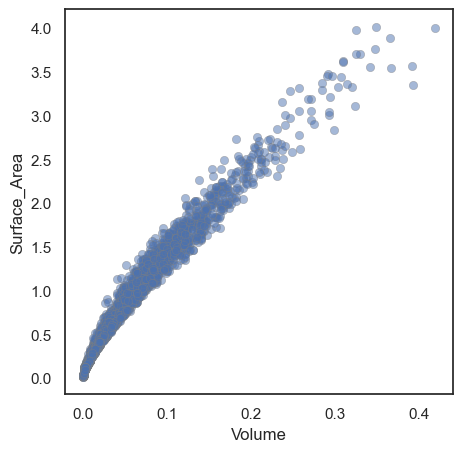

In [52]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
sns.set_style('white')


plt.figure(figsize = (5, 5)) # determines the size of the plot area
ax = sns.scatterplot(x="Volume", y="Surface_Area",data=df,edgecolor='grey',alpha=0.5) # sns, using seaborn, similar to matplotlib

You can see that Volume correlates with Surface_Area as expected.  